# Client Evaluation

This File reads all csv files of the ./client folder and concatenates them to a single dataframe, then used for further evaluation.

In [28]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [30]:
df

,Transport Protocol,Scenario,Distance (m),Average RTT (ms),Jitter (ms)
0,TCP,Inner City,30,40.581468,9.434658
1,TCP,Inner City,30,80.728576,9.920612
2,UDP,Inner City,1,187.808201,17.577383
3,QUIC,Inner City,1,93.862499,18.088233
4,TCP,Inner City,1,214.867481,15.337571
5,TCP,Inner City,1,169.109420,13.577824
6,TCP,Inner City,30,176.841718,8.821120
7,TCP,Inner City,10,230.785190,9.303844
8,TCP,Inner City,10,198.153996,8.842113
9,UDP,Inner City,10,51.345034,7.800252


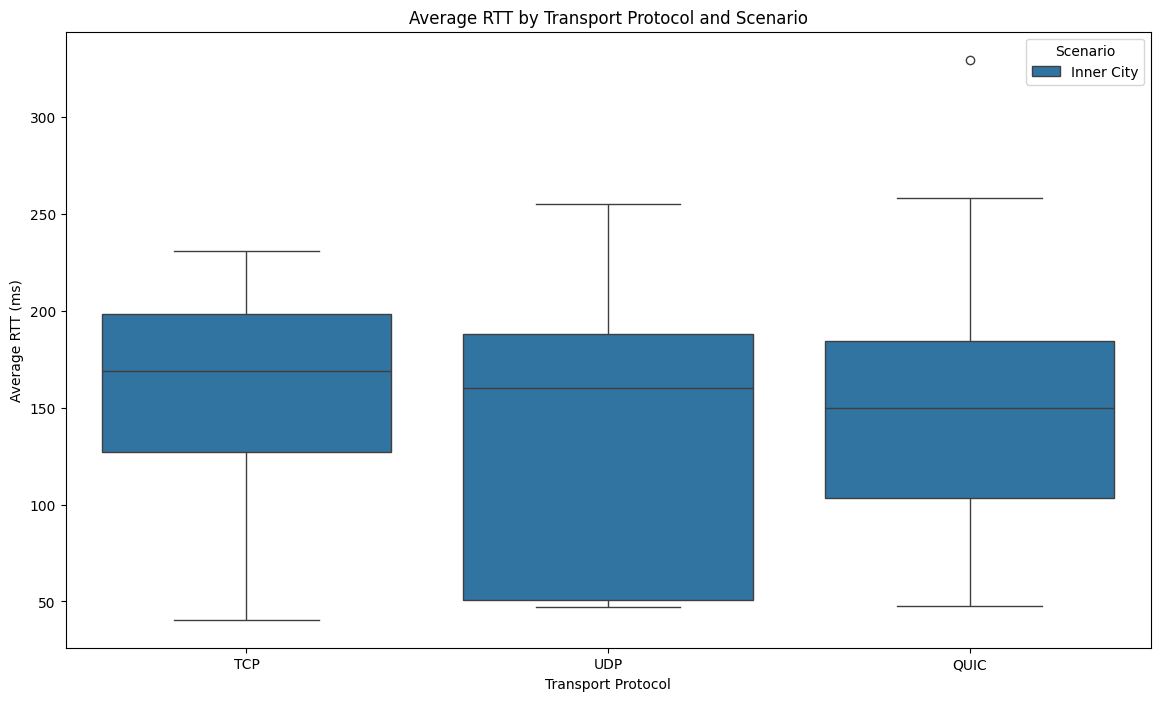

In [31]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Transport Protocol', y='Average RTT (ms)', hue='Scenario', data=df)
plt.title('Average RTT by Transport Protocol and Scenario')
plt.ylabel('Average RTT (ms)')
plt.xlabel('Transport Protocol')
plt.legend(title='Scenario')
plt.show()

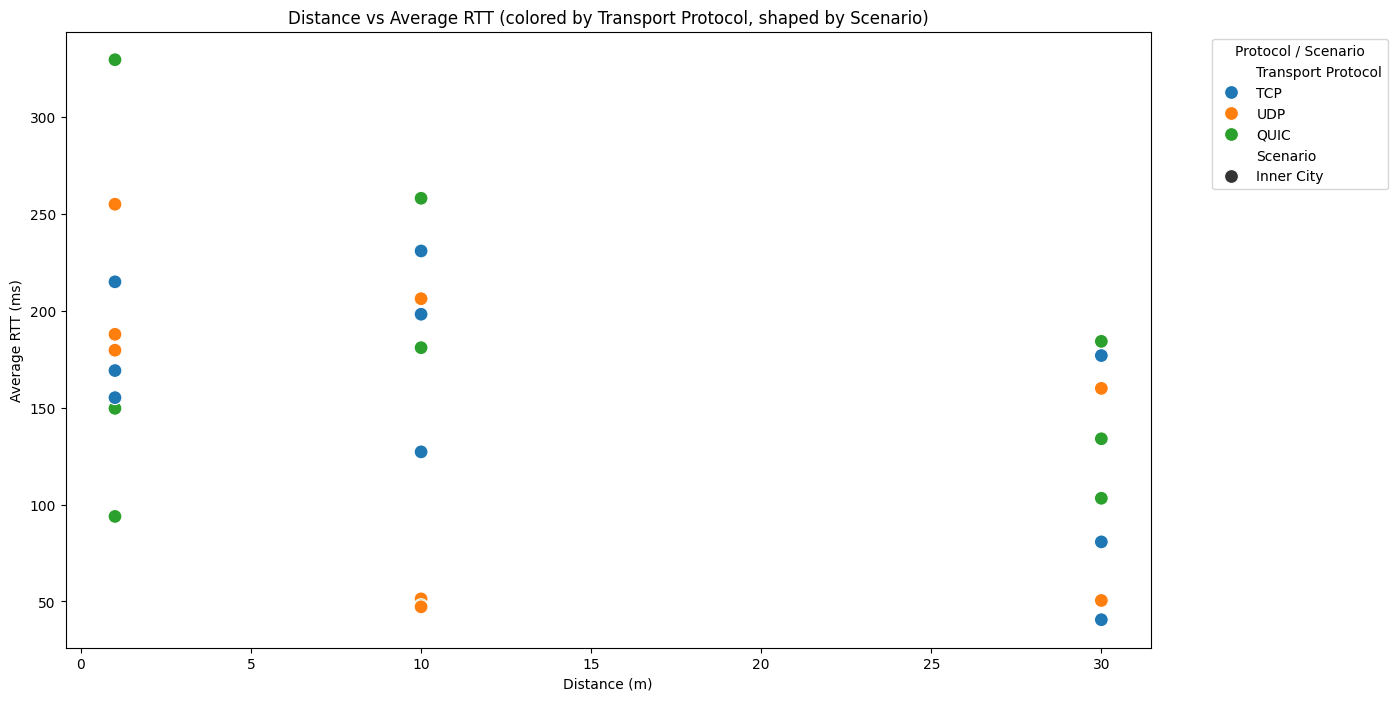

In [32]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Distance (m)', y='Average RTT (ms)', hue='Transport Protocol', style='Scenario', data=df, s=100)
plt.title('Distance vs Average RTT (colored by Transport Protocol, shaped by Scenario)')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

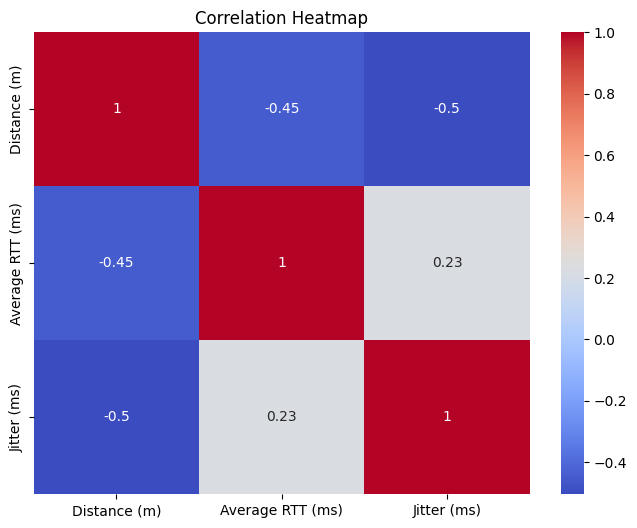

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()